# 🤖 Model Evaluation & Optimization
---
**Topics:**
| S.No | Topic |
|---|-------|
| 1 | Model Evaluation Metrics (Accuracy, Precision, Recall, F1-Score) |
| 2 | Confusion Matrix |
| 3 | Cross-Validation |
| 4 | Hyperparameter Tuning Basics |
| 5 | 🚀 Mini Project: End-to-End ML Pipeline |

> **Learning Goal:** By end of this session, you'll be able to build, evaluate, and optimize ML models!


## ⚙️ Setup — Install & Import Libraries

In [1]:
# Install required libraries
!pip install scikit-learn matplotlib seaborn pandas numpy -q

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — datasets
from sklearn.datasets import load_iris, load_breast_cancer, make_classification

# Sklearn — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Sklearn — evaluation
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold,
    StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')
print('🐍 Python environment ready.')

✅ All libraries imported successfully!
🐍 Python environment ready.


---

# 📊 Part 1: Model Evaluation Metrics

## 🧠 Theory First

After training a model, we need to measure **how good** it is. Here are the key metrics:

### 🎯 The 4 Core Metrics

| Metric | Formula | When to Use |
|--------|---------|-------------|
| **Accuracy** | (TP + TN) / (TP + FP + FN + TN) | Balanced datasets |
| **Precision** | TP / (TP + FP) | When False Positives are costly (e.g., spam filter) |
| **Recall** | TP / (TP + FN) | When False Negatives are costly (e.g., cancer detection) |
| **F1-Score** | 2 × (P × R) / (P + R) | Imbalanced datasets |

### 🔤 Key Terms
- **TP** = True Positive (Correctly predicted Positive)
- **TN** = True Negative (Correctly predicted Negative)
- **FP** = False Positive (Predicted Positive, actually Negative) ← Type I Error
- **FN** = False Negative (Predicted Negative, actually Positive) ← Type II Error

In [2]:
# ============================================================
# 📌 DEMO 1: Understanding Metrics with a Simple Example
# ============================================================

# Simulated actual vs predicted labels (Binary classification)
y_actual   = [1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
               1, 1, 0, 0, 1, 0, 1, 1, 0, 0]
y_predicted = [1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
                1, 0, 0, 1, 1, 0, 1, 0, 0, 1]

# --- Calculate each metric ---
acc  = accuracy_score(y_actual, y_predicted)
prec = precision_score(y_actual, y_predicted)
rec  = recall_score(y_actual, y_predicted)
f1   = f1_score(y_actual, y_predicted)

print('=' * 50)
print('        📊 EVALUATION METRICS SUMMARY')
print('=' * 50)
print(f'  ✅ Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  🎯 Precision : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  🔍 Recall    : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  ⚖️  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)')
print('=' * 50)

# --- Full classification report ---
print('\n📋 Full Classification Report:')
print(classification_report(y_actual, y_predicted,
                            target_names=['Negative', 'Positive']))

        📊 EVALUATION METRICS SUMMARY
  ✅ Accuracy  : 0.7000  (70.00%)
  🎯 Precision : 0.7000  (70.00%)
  🔍 Recall    : 0.7000  (70.00%)
  ⚖️  F1-Score  : 0.7000  (70.00%)

📋 Full Classification Report:
              precision    recall  f1-score   support

    Negative       0.70      0.70      0.70        10
    Positive       0.70      0.70      0.70        10

    accuracy                           0.70        20
   macro avg       0.70      0.70      0.70        20
weighted avg       0.70      0.70      0.70        20



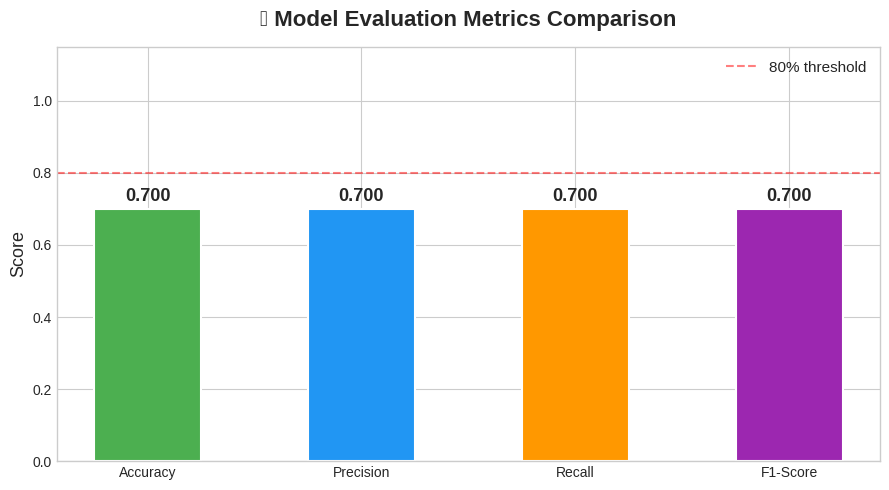


💡 Insight:
   - Accuracy alone can be misleading for imbalanced datasets!
   - Always check Precision, Recall, and F1 together.


In [3]:
# ============================================================
# 📌 DEMO 2: Visual Comparison of Metrics
# ============================================================

metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
colors  = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics.keys(), metrics.values(), color=colors, width=0.5,
              edgecolor='white', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.set_ylim(0, 1.15)
ax.set_title('📊 Model Evaluation Metrics Comparison', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontsize=13)
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('\n💡 Insight:')
print('   - Accuracy alone can be misleading for imbalanced datasets!')
print('   - Always check Precision, Recall, and F1 together.')

In [4]:
# ============================================================
# 📌 DEMO 3: Real Dataset — Breast Cancer Classification
# ============================================================

# Load dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print(f'Dataset: Breast Cancer Wisconsin')
print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]}')
print(f'Classes  : {cancer.target_names}  →  {np.bincount(y)}')

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Compare multiple models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5)
}

results = []
print('\n🔄 Training models...')
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    results.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred)
    })
    print(f'  ✅ {name} done')

results_df = pd.DataFrame(results).set_index('Model')
print('\n📊 Model Comparison:')
print(results_df.round(4).to_string())

Dataset: Breast Cancer Wisconsin
Features : 30
Samples  : 569
Classes  : ['malignant' 'benign']  →  [212 357]

🔄 Training models...
  ✅ Logistic Regression done
  ✅ Decision Tree done
  ✅ Random Forest done
  ✅ SVM done
  ✅ KNN done

📊 Model Comparison:
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.9825     0.9861  0.9861    0.9861
Decision Tree          0.9123     0.9559  0.9028    0.9286
Random Forest          0.9561     0.9589  0.9722    0.9655
SVM                    0.9825     0.9861  0.9861    0.9861
KNN                    0.9561     0.9589  0.9722    0.9655


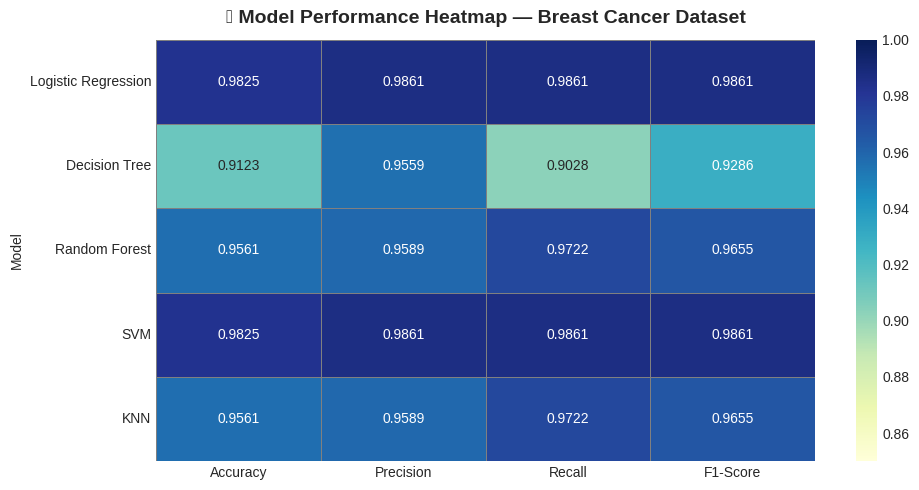

In [5]:
# ============================================================
# 📌 DEMO 4: Visual Model Comparison Heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(results_df, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, linecolor='gray', ax=ax,
            vmin=0.85, vmax=1.0)
ax.set_title('🔥 Model Performance Heatmap — Breast Cancer Dataset',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---

# 🟦 Part 2: Confusion Matrix

## 🧠 What is a Confusion Matrix?

A **Confusion Matrix** is a table showing predicted vs actual values. It's the foundation for all classification metrics.

```
                  PREDICTED
                Negative  Positive
ACTUAL Negative  [ TN  |  FP ]
       Positive  [ FN  |  TP ]
```

- **Diagonal** = Correct predictions
- **Off-diagonal** = Errors

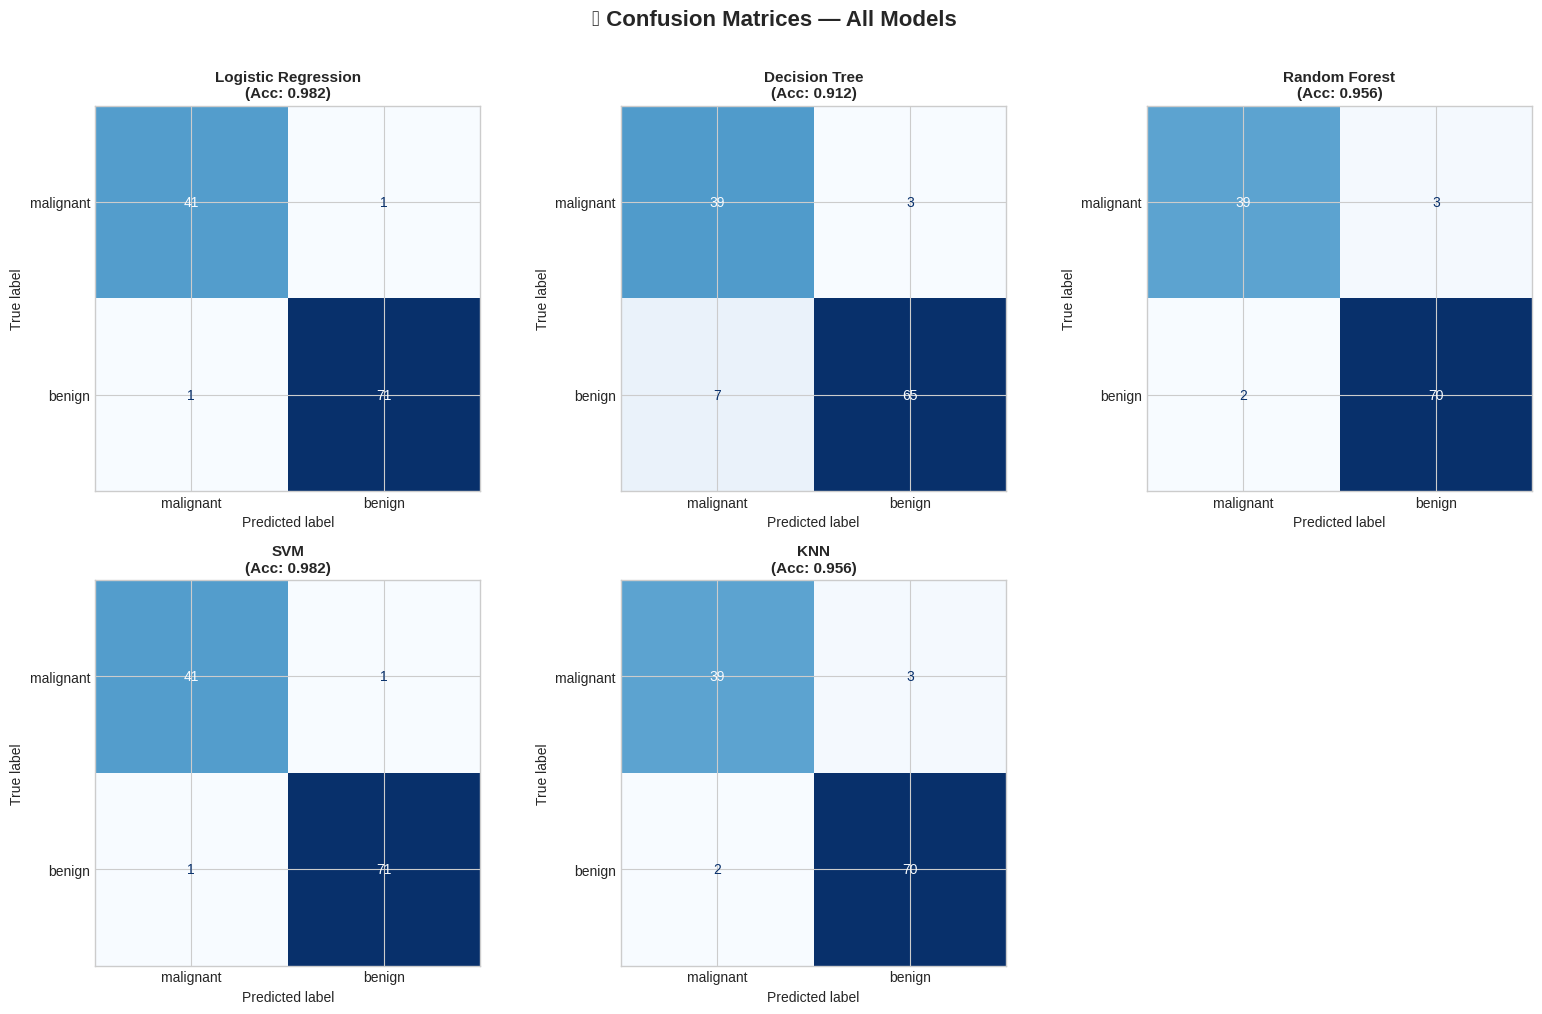

In [6]:
# ============================================================
# 📌 DEMO 5: Confusion Matrix — Multiple Models Side by Side
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=cancer.target_names
    )
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{name}\n(Acc: {accuracy_score(y_test, y_pred):.3f})',
                         fontsize=11, fontweight='bold')

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle('🟦 Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 📌 DEMO 6: Manual Confusion Matrix Breakdown
# ============================================================

# Use Random Forest (best model)
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test_sc)
cm = confusion_matrix(y_test, y_pred_rf)

tn, fp, fn, tp = cm.ravel()

print('=' * 55)
print('   🟦 CONFUSION MATRIX BREAKDOWN — Random Forest')
print('=' * 55)
print(f'\n   Confusion Matrix:\n')
print(f'              Predicted')
print(f'              Malignant  Benign')
print(f'  Actual Malignant  {tn:5d}    {fp:5d}')
print(f'         Benign    {fn:5d}    {tp:5d}')
print()
print(f'  ✅ True  Positive (TP) = {tp}  → Correctly predicted Benign')
print(f'  ✅ True  Negative (TN) = {tn}  → Correctly predicted Malignant')
print(f'  ❌ False Positive (FP) = {fp}   → Predicted Benign, actually Malignant')
print(f'  ❌ False Negative (FN) = {fn}   → Predicted Malignant, actually Benign')
print('=' * 55)
print(f'\n  📌 In cancer detection, FN is most dangerous!')
print(f'     (Missed cancer case = delayed treatment)')

   🟦 CONFUSION MATRIX BREAKDOWN — Random Forest

   Confusion Matrix:

              Predicted
              Malignant  Benign
  Actual Malignant     39        3
         Benign        2       70

  ✅ True  Positive (TP) = 70  → Correctly predicted Benign
  ✅ True  Negative (TN) = 39  → Correctly predicted Malignant
  ❌ False Positive (FP) = 3   → Predicted Benign, actually Malignant
  ❌ False Negative (FN) = 2   → Predicted Malignant, actually Benign

  📌 In cancer detection, FN is most dangerous!
     (Missed cancer case = delayed treatment)


---

# 🔄 Part 3: Cross-Validation

## 🧠 Why Cross-Validation?

A single train/test split can be **lucky or unlucky**. Cross-validation gives a more **reliable estimate** of model performance.

```
K-Fold Cross Validation (K=5):

Fold 1: [TEST ] [TRAIN] [TRAIN] [TRAIN] [TRAIN]
Fold 2: [TRAIN] [TEST ] [TRAIN] [TRAIN] [TRAIN]
Fold 3: [TRAIN] [TRAIN] [TEST ] [TRAIN] [TRAIN]
Fold 4: [TRAIN] [TRAIN] [TRAIN] [TEST ] [TRAIN]
Fold 5: [TRAIN] [TRAIN] [TRAIN] [TRAIN] [TEST ]

Final Score = Average of all 5 fold scores
```

In [8]:
# ============================================================
# 📌 DEMO 7: K-Fold Cross-Validation
# ============================================================

from sklearn.datasets import load_iris

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

scaler_iris = StandardScaler()
X_iris_sc = scaler_iris.fit_transform(X_iris)

model_cv = RandomForestClassifier(n_estimators=100, random_state=42)

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_cv, X_iris_sc, y_iris, cv=kf, scoring='accuracy')

print('🔄 5-Fold Cross-Validation Results (Iris Dataset):')
print('─' * 40)
for i, score in enumerate(cv_scores, 1):
    bar = '█' * int(score * 30)
    print(f'  Fold {i}: {score:.4f}  {bar}')
print('─' * 40)
print(f'  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Min   : {cv_scores.min():.4f}')
print(f'  Max   : {cv_scores.max():.4f}')

🔄 5-Fold Cross-Validation Results (Iris Dataset):
────────────────────────────────────────
  Fold 1: 1.0000  ██████████████████████████████
  Fold 2: 0.9667  █████████████████████████████
  Fold 3: 0.9333  ████████████████████████████
  Fold 4: 0.9333  ████████████████████████████
  Fold 5: 0.9667  █████████████████████████████
────────────────────────────────────────
  Mean  : 0.9600 ± 0.0249
  Min   : 0.9333
  Max   : 1.0000


  K= 3 → Mean Accuracy: 0.9533 ± 0.0189
  K= 5 → Mean Accuracy: 0.9467 ± 0.0267
  K= 7 → Mean Accuracy: 0.9598 ± 0.0388
  K=10 → Mean Accuracy: 0.9467 ± 0.0581


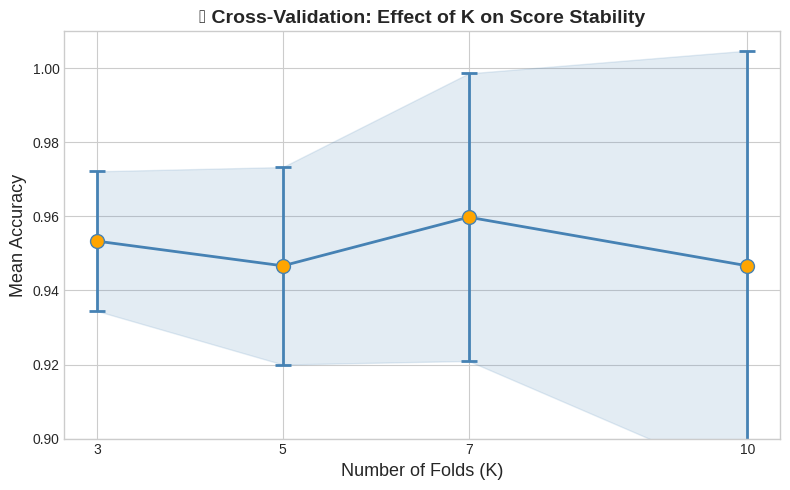

In [9]:
# ============================================================
# 📌 DEMO 8: Comparing K Values in Cross-Validation
# ============================================================

k_values = [3, 5, 7, 10]
all_means = []
all_stds  = []

for k in k_values:
    kf_temp = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores  = cross_val_score(model_cv, X_iris_sc, y_iris, cv=kf_temp)
    all_means.append(scores.mean())
    all_stds.append(scores.std())
    print(f'  K={k:2d} → Mean Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(k_values, all_means, yerr=all_stds, fmt='o-', color='steelblue',
            capsize=6, capthick=2, linewidth=2, markersize=10, markerfacecolor='orange')
ax.fill_between(k_values,
                [m - s for m, s in zip(all_means, all_stds)],
                [m + s for m, s in zip(all_means, all_stds)],
                alpha=0.15, color='steelblue')
ax.set_xlabel('Number of Folds (K)', fontsize=13)
ax.set_ylabel('Mean Accuracy', fontsize=13)
ax.set_title('🔄 Cross-Validation: Effect of K on Score Stability',
             fontsize=14, fontweight='bold')
ax.set_xticks(k_values)
ax.set_ylim(0.9, 1.01)
plt.tight_layout()
plt.show()

🔄 Running 5-Fold Stratified Cross-Validation on all models...
  Logistic Regression    → 0.9825 ± 0.0078
  Decision Tree          → 0.9319 ± 0.0144
  Random Forest          → 0.9699 ± 0.0146
  SVM                    → 0.9738 ± 0.0122
  KNN                    → 0.9688 ± 0.0090


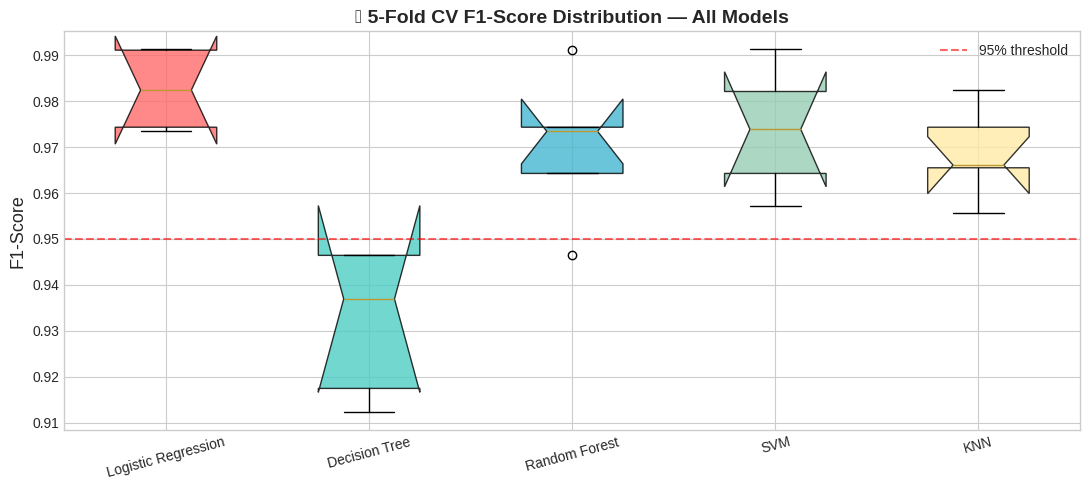

In [10]:
# ============================================================
# 📌 DEMO 9: Cross-Validation — All Models Compared
# ============================================================

cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('🔄 Running 5-Fold Stratified Cross-Validation on all models...')
for name, model in models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='f1')
    cv_results[name] = scores
    print(f'  {name:22s} → {scores.mean():.4f} ± {scores.std():.4f}')

# Boxplot
fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(cv_results.values(), labels=cv_results.keys(),
                patch_artist=True, notch=True)
colors_box = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title('📦 5-Fold CV F1-Score Distribution — All Models',
             fontsize=14, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=13)
ax.set_xticklabels(cv_results.keys(), rotation=15)
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.6, label='95% threshold')
ax.legend()
plt.tight_layout()
plt.show()

---

# ⚙️ Part 4: Hyperparameter Tuning

## 🧠 What are Hyperparameters?

| Type | Description | Example |
|------|------------|--------|
| **Parameters** | Learned during training | weights, biases |
| **Hyperparameters** | Set BEFORE training | `n_estimators`, `max_depth`, `C` |

### 🔧 Tuning Strategies
1. **Grid Search** — Try every combination (exhaustive, slow)
2. **Random Search** — Try random combinations (faster, often better)
3. **Bayesian Optimization** — Smart search using past results (most efficient)

In [11]:
# ============================================================
# 📌 DEMO 10: Grid Search CV
# ============================================================

print('⚙️ Grid Search Hyperparameter Tuning — Random Forest')
print('─' * 50)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

total_combinations = 3 * 4 * 3
print(f'  Parameter Grid:')
for k, v in param_grid.items():
    print(f'    {k}: {v}')
print(f'  Total Combinations: {total_combinations} × 5 folds = {total_combinations*5} fits')
print()

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf_base, param_grid, cv=5,
    scoring='f1', n_jobs=-1, verbose=0
)

print('🔄 Running Grid Search...')
grid_search.fit(X_train_sc, y_train)

print(f'\n  ✅ Best Parameters : {grid_search.best_params_}')
print(f'  ✅ Best CV Score   : {grid_search.best_score_:.4f}')

# Test on held-out data
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_sc)
print(f'  ✅ Test F1-Score   : {f1_score(y_test, y_pred_best):.4f}')

⚙️ Grid Search Hyperparameter Tuning — Random Forest
──────────────────────────────────────────────────
  Parameter Grid:
    n_estimators: [50, 100, 200]
    max_depth: [None, 5, 10, 20]
    min_samples_split: [2, 5, 10]
  Total Combinations: 36 × 5 folds = 180 fits

🔄 Running Grid Search...

  ✅ Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  ✅ Best CV Score   : 0.9684
  ✅ Test F1-Score   : 0.9655


In [12]:
# ============================================================
# 📌 DEMO 11: Random Search CV
# ============================================================

from scipy.stats import randint

print('⚙️ Random Search Hyperparameter Tuning — Random Forest')
print('─' * 50)

param_dist = {
    'n_estimators'      : randint(50, 300),
    'max_depth'         : [None, 5, 10, 15, 20, 25],
    'min_samples_split' : randint(2, 20),
    'min_samples_leaf'  : randint(1, 10),
    'max_features'      : ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,           # Only try 30 random combinations
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

print('🔄 Running Random Search (30 iterations × 5 folds = 150 fits)...')
random_search.fit(X_train_sc, y_train)

print(f'\n  ✅ Best Parameters : {random_search.best_params_}')
print(f'  ✅ Best CV Score   : {random_search.best_score_:.4f}')

best_rs_model = random_search.best_estimator_
y_pred_rs = best_rs_model.predict(X_test_sc)
print(f'  ✅ Test F1-Score   : {f1_score(y_test, y_pred_rs):.4f}')

print('\n📌 Grid Search vs Random Search:')
print(f'   Grid Search  → Best F1: {f1_score(y_test, y_pred_best):.4f} | 180 fits')
print(f'   Random Search → Best F1: {f1_score(y_test, y_pred_rs):.4f} | 150 fits')

⚙️ Random Search Hyperparameter Tuning — Random Forest
──────────────────────────────────────────────────
🔄 Running Random Search (30 iterations × 5 folds = 150 fits)...

  ✅ Best Parameters : {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 283}
  ✅ Best CV Score   : 0.9684
  ✅ Test F1-Score   : 0.9583

📌 Grid Search vs Random Search:
   Grid Search  → Best F1: 0.9655 | 180 fits
   Random Search → Best F1: 0.9583 | 150 fits


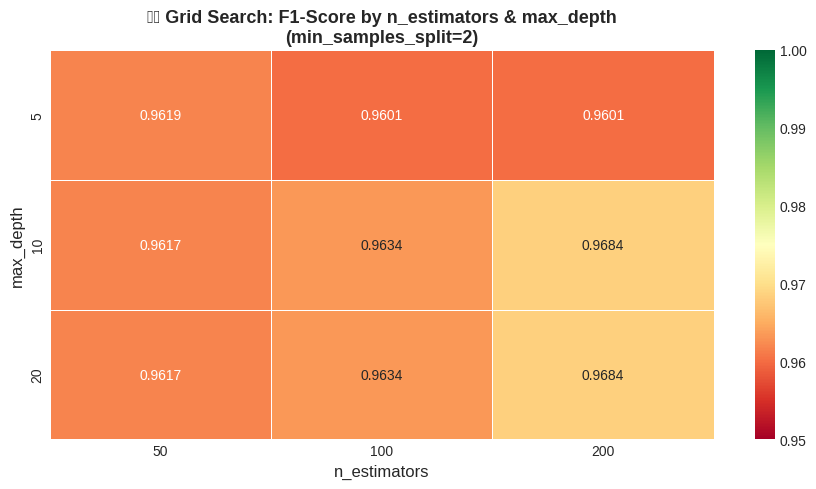

In [13]:
# ============================================================
# 📌 DEMO 12: Visualizing Grid Search Results
# ============================================================

cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Pivot for heatmap: n_estimators vs max_depth (for min_samples_split=2)
pivot_data = cv_results_df[
    cv_results_df['param_min_samples_split'] == 2
].pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators'
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='RdYlGn',
            ax=ax, linewidths=0.5, vmin=0.95, vmax=1.0)
ax.set_title('⚙️ Grid Search: F1-Score by n_estimators & max_depth\n(min_samples_split=2)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('n_estimators', fontsize=12)
ax.set_ylabel('max_depth', fontsize=12)
plt.tight_layout()
plt.show()

---

# 📈 ROC Curve & AUC

The **ROC Curve** (Receiver Operating Characteristic) shows model performance across all classification thresholds.
**AUC** = Area Under the Curve → closer to 1.0 = better model.

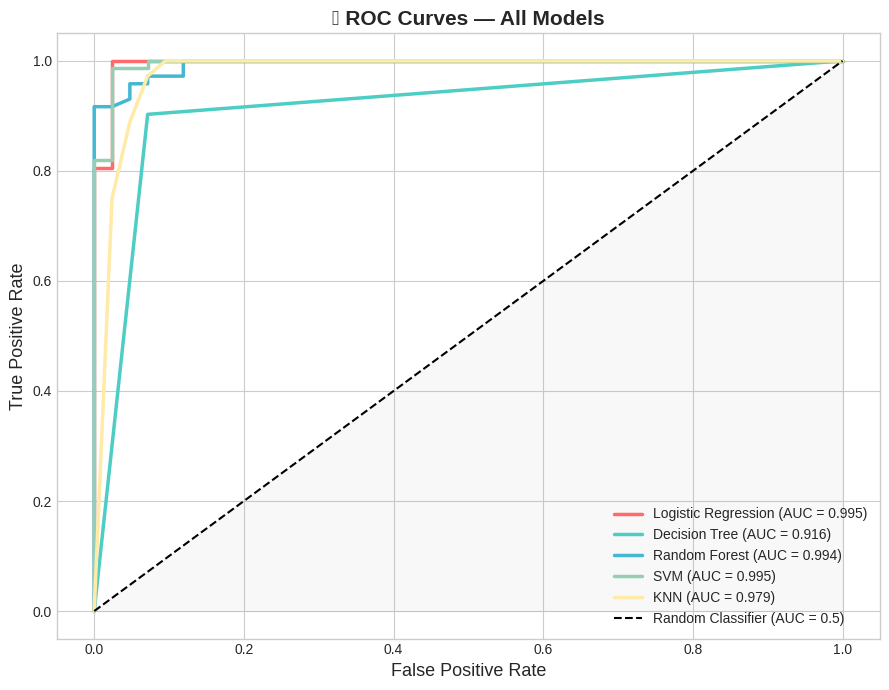

In [14]:
# ============================================================
# 📌 DEMO 13: ROC Curve for All Models
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for (name, model), color in zip(models.items(), colors_roc):
    # Get probability scores
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        y_prob = model.decision_function(X_test_sc)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('📈 ROC Curves — All Models', fontsize=15, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

---

# 🚀 MINI PROJECT: End-to-End ML Pipeline

## 📌 Project: Titanic Survival Prediction
**Goal:** Predict whether a passenger survived the Titanic disaster.

### 📋 Pipeline Steps:
1. 📂 Dataset Loading & EDA
2. 🔧 Feature Engineering & Preprocessing
3. 🤖 Model Training
4. 📊 Evaluation (Confusion Matrix, Metrics, ROC)
5. ⚙️ Hyperparameter Tuning
6. 🏆 Final Results


In [15]:
# ============================================================
# 🚀 MINI PROJECT — STEP 1: Dataset Loading & EDA
# ============================================================

# Using seaborn's built-in Titanic dataset
titanic = sns.load_dataset('titanic')

print('📂 Titanic Dataset Loaded!')
print(f'   Shape: {titanic.shape}')
print(f'   Columns: {list(titanic.columns)}')
print()
print('📊 First 5 rows:')
titanic.head()

📂 Titanic Dataset Loaded!
   Shape: (891, 15)
   Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

📊 First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


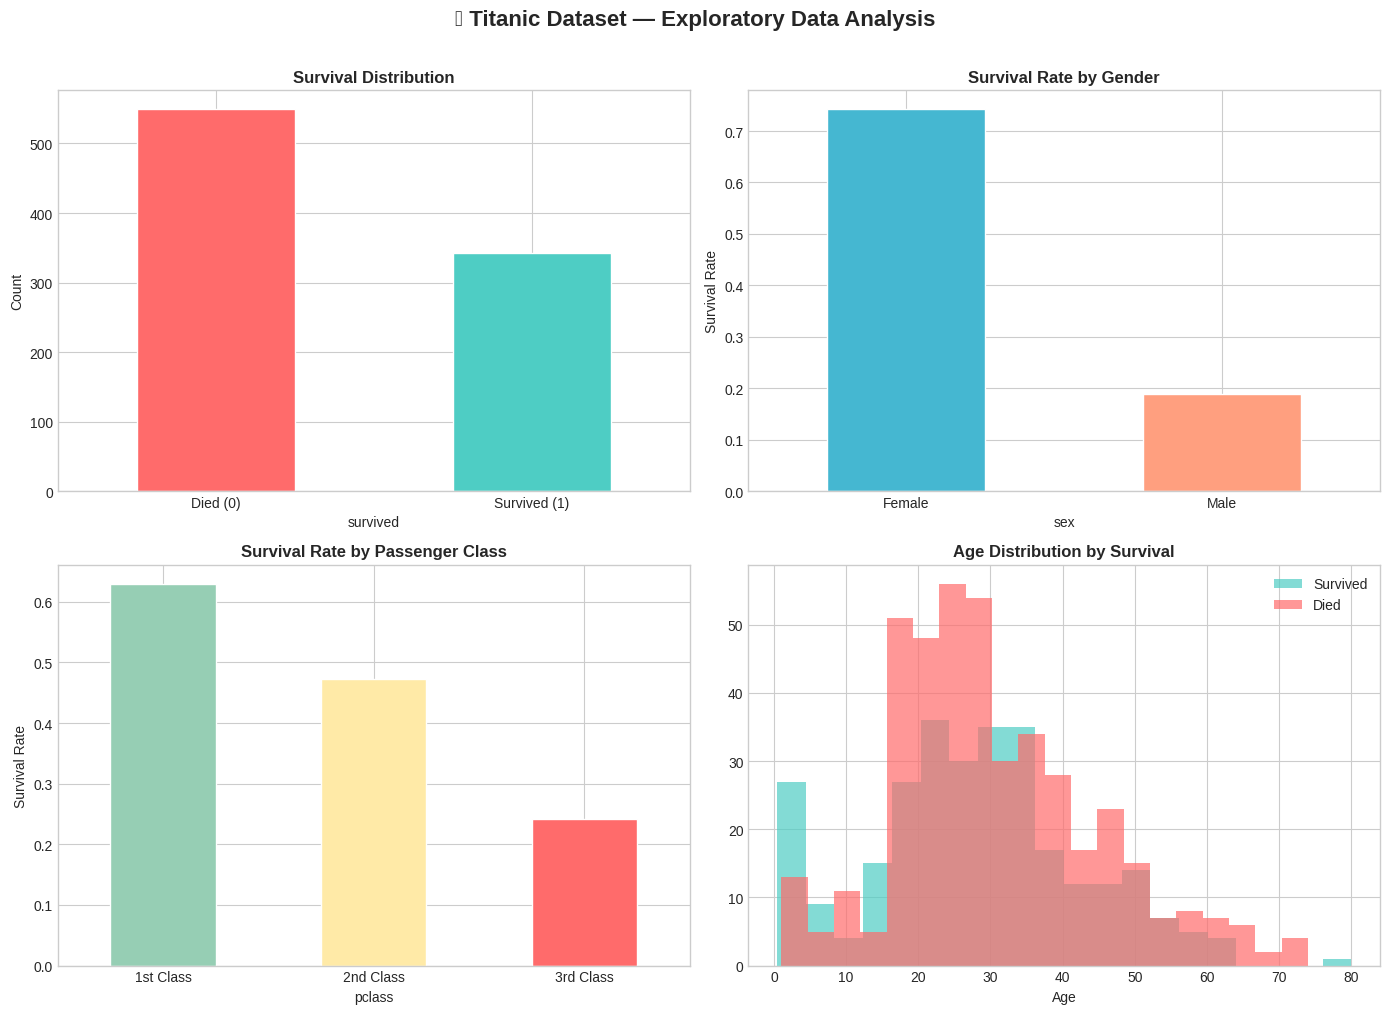

In [16]:
# ============================================================
# 🚀 MINI PROJECT — STEP 1b: Exploratory Data Analysis
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival distribution
titanic['survived'].value_counts().plot(kind='bar', ax=axes[0,0],
    color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
axes[0,0].set_title('Survival Distribution', fontweight='bold')
axes[0,0].set_xticklabels(['Died (0)', 'Survived (1)'], rotation=0)
axes[0,0].set_ylabel('Count')

# Survival by sex
titanic.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0,1],
    color=['#45B7D1', '#FF9F7F'], edgecolor='white')
axes[0,1].set_title('Survival Rate by Gender', fontweight='bold')
axes[0,1].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0,1].set_ylabel('Survival Rate')

# Survival by class
titanic.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[1,0],
    color=['#96CEB4', '#FFEAA7', '#FF6B6B'], edgecolor='white')
axes[1,0].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[1,0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'], rotation=0)
axes[1,0].set_ylabel('Survival Rate')

# Age distribution by survival
titanic[titanic['survived']==1]['age'].dropna().hist(
    ax=axes[1,1], color='#4ECDC4', alpha=0.7, bins=20, label='Survived')
titanic[titanic['survived']==0]['age'].dropna().hist(
    ax=axes[1,1], color='#FF6B6B', alpha=0.7, bins=20, label='Died')
axes[1,1].set_title('Age Distribution by Survival', fontweight='bold')
axes[1,1].set_xlabel('Age')
axes[1,1].legend()

fig.suptitle('🚢 Titanic Dataset — Exploratory Data Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 🚀 MINI PROJECT — STEP 2: Feature Engineering & Preprocessing
# ============================================================

df = titanic.copy()

# --- 1. Handle Missing Values ---
print('🔍 Missing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
df.dropna(subset=['fare'], inplace=True)

# --- 2. Feature Engineering ---
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone']    = (df['family_size'] == 1).astype(int)
df['age_group']   = pd.cut(df['age'], bins=[0,12,18,35,60,100],
                            labels=['child','teen','adult','mid','senior'])

# --- 3. Encode Categorical Variables ---
df['sex_enc'] = (df['sex'] == 'female').astype(int)
df['embarked_enc'] = LabelEncoder().fit_transform(df['embarked'].astype(str))
df['age_group_enc'] = LabelEncoder().fit_transform(df['age_group'].astype(str))

# --- 4. Select Features ---
features = ['pclass', 'sex_enc', 'age', 'fare', 'family_size',
            'is_alone', 'embarked_enc', 'age_group_enc']
target   = 'survived'

X_titan = df[features]
y_titan = df[target]

print(f'\n✅ Final Feature Set: {features}')
print(f'   Dataset shape: {X_titan.shape}')
print(f'   Class balance: {y_titan.value_counts().to_dict()}')

🔍 Missing Values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

✅ Final Feature Set: ['pclass', 'sex_enc', 'age', 'fare', 'family_size', 'is_alone', 'embarked_enc', 'age_group_enc']
   Dataset shape: (891, 8)
   Class balance: {0: 549, 1: 342}


In [18]:
# ============================================================
# 🚀 MINI PROJECT — STEP 3: Model Training & Evaluation
# ============================================================

# Split & Scale
X_tr, X_te, y_tr, y_te = train_test_split(
    X_titan, y_titan, test_size=0.2, random_state=42, stratify=y_titan
)

sc_titan = StandardScaler()
X_tr_sc = sc_titan.fit_transform(X_tr)
X_te_sc = sc_titan.transform(X_te)

# Train multiple models
titan_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(probability=True, random_state=42),
    'KNN'                : KNeighborsClassifier(n_neighbors=5)
}

print('🚀 Training models on Titanic dataset...')
print('─' * 65)
print(f'{"Model":25s} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print('─' * 65)

titan_results = {}
for name, model in titan_models.items():
    model.fit(X_tr_sc, y_tr)
    y_pr = model.predict(X_te_sc)
    titan_results[name] = {
        'model': model, 'pred': y_pr,
        'acc' : accuracy_score(y_te, y_pr),
        'prec': precision_score(y_te, y_pr),
        'rec' : recall_score(y_te, y_pr),
        'f1'  : f1_score(y_te, y_pr)
    }
    r = titan_results[name]
    print(f'{name:25s} {r["acc"]:>10.4f} {r["prec"]:>10.4f} {r["rec"]:>8.4f} {r["f1"]:>8.4f}')

print('─' * 65)

🚀 Training models on Titanic dataset...
─────────────────────────────────────────────────────────────────
Model                       Accuracy  Precision   Recall       F1
─────────────────────────────────────────────────────────────────
Logistic Regression           0.7989     0.7619   0.6957   0.7273
Random Forest                 0.8045     0.7656   0.7101   0.7368
SVM                           0.8212     0.8491   0.6522   0.7377
KNN                           0.8101     0.7869   0.6957   0.7385
─────────────────────────────────────────────────────────────────


🏆 Best Model: KNN (F1 = 0.7385)



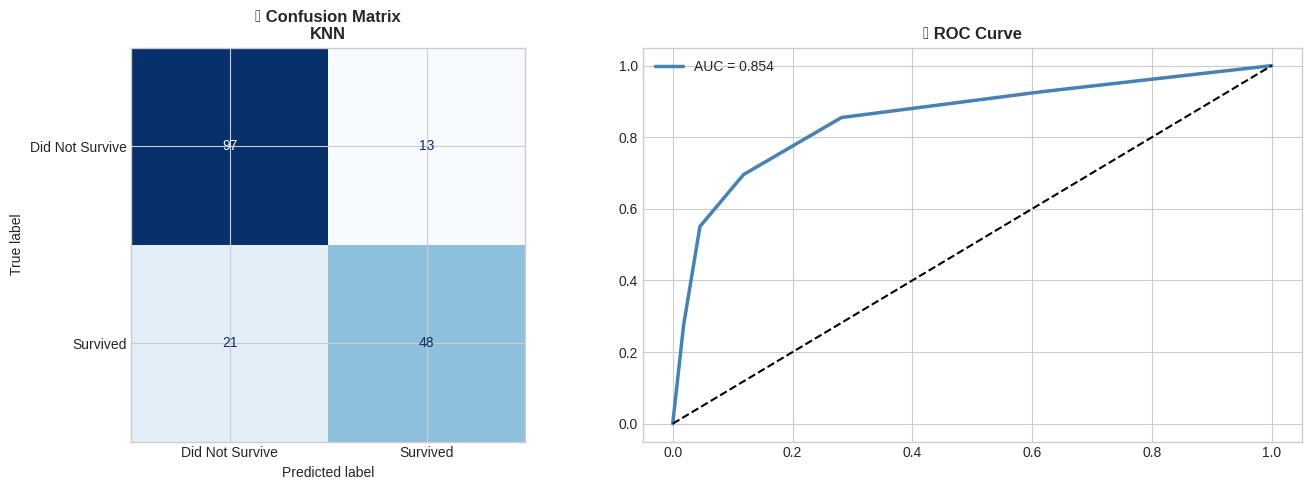


📋 Detailed Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



In [19]:
# ============================================================
# 🚀 MINI PROJECT — STEP 4: Best Model Deep Dive
# ============================================================

# Find best model by F1
best_name = max(titan_results, key=lambda k: titan_results[k]['f1'])
best_info = titan_results[best_name]

print(f'🏆 Best Model: {best_name} (F1 = {best_info["f1"]:.4f})')
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_te, best_info['pred'])
ConfusionMatrixDisplay(cm, display_labels=['Did Not Survive', 'Survived']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'🟦 Confusion Matrix\n{best_name}', fontweight='bold', fontsize=12)

# Feature Importance (if Random Forest)
if best_name == 'Random Forest':
    importances = best_info['model'].feature_importances_
    feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)
    feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('🌟 Feature Importances', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Importance Score')
else:
    # ROC curve
    y_prob = best_info['model'].predict_proba(X_te_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    axes[1].plot(fpr, tpr, color='steelblue', linewidth=2.5,
                 label=f'AUC = {auc(fpr,tpr):.3f}')
    axes[1].plot([0,1],[0,1],'k--')
    axes[1].set_title('📈 ROC Curve', fontweight='bold')
    axes[1].legend()

plt.tight_layout()
plt.show()

print('\n📋 Detailed Classification Report:')
print(classification_report(y_te, best_info['pred'],
      target_names=['Did Not Survive', 'Survived']))

In [20]:
# ============================================================
# 🚀 MINI PROJECT — STEP 5: Hyperparameter Tuning
# ============================================================

print('⚙️ Hyperparameter Tuning — Random Forest on Titanic')
print('─' * 50)

param_grid_titan = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [3, 5, 10, None],
    'min_samples_leaf': [1, 2, 5]
}

rf_titan = RandomForestClassifier(random_state=42)
gs_titan = GridSearchCV(rf_titan, param_grid_titan, cv=5,
                        scoring='f1', n_jobs=-1, verbose=0)

print('🔄 Running Grid Search...')
gs_titan.fit(X_tr_sc, y_tr)

print(f'\n  ✅ Best Params  : {gs_titan.best_params_}')
print(f'  ✅ Best CV F1   : {gs_titan.best_score_:.4f}')

y_pred_tuned = gs_titan.best_estimator_.predict(X_te_sc)
baseline_f1 = titan_results['Random Forest']['f1']
tuned_f1    = f1_score(y_te, y_pred_tuned)

print(f'\n  📊 Before Tuning → F1: {baseline_f1:.4f}')
print(f'  📊 After Tuning  → F1: {tuned_f1:.4f}')
print(f'  📈 Improvement   → +{(tuned_f1 - baseline_f1)*100:.2f}%')

⚙️ Hyperparameter Tuning — Random Forest on Titanic
──────────────────────────────────────────────────
🔄 Running Grid Search...

  ✅ Best Params  : {'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 50}
  ✅ Best CV F1   : 0.7490

  📊 Before Tuning → F1: 0.7368
  📊 After Tuning  → F1: 0.6842
  📈 Improvement   → +-5.26%


In [21]:
# ============================================================
# 🚀 MINI PROJECT — STEP 6: Final Summary Dashboard
# ============================================================

print('\n' + '='*60)
print('     🏆 MINI PROJECT FINAL RESULTS — TITANIC SURVIVAL')
print('='*60)

# All metrics in one table
summary = []
for name, info in titan_results.items():
    cv_sc = cross_val_score(info['model'], X_tr_sc, y_tr, cv=5, scoring='f1')
    summary.append({
        'Model'        : name,
        'Accuracy'     : round(info['acc'],  4),
        'Precision'    : round(info['prec'], 4),
        'Recall'       : round(info['rec'],  4),
        'F1-Score'     : round(info['f1'],   4),
        'CV Mean (F1)' : round(cv_sc.mean(), 4)
    })

summary_df = pd.DataFrame(summary).set_index('Model')
summary_df['Rank'] = summary_df['F1-Score'].rank(ascending=False).astype(int)
summary_df = summary_df.sort_values('F1-Score', ascending=False)

print(summary_df.to_string())
print('='*60)

best_model_name = summary_df.index[0]
print(f'\n🥇 Winner: {best_model_name}')
print(f'   F1-Score : {summary_df["F1-Score"].iloc[0]}')
print(f'   Accuracy : {summary_df["Accuracy"].iloc[0]}')
print()
print('✅ Project Complete! Key Takeaways:')
print('   1. Always evaluate with multiple metrics')
print('   2. Cross-validation gives reliable estimates')
print('   3. Hyperparameter tuning can improve results')
print('   4. Feature engineering matters!')


     🏆 MINI PROJECT FINAL RESULTS — TITANIC SURVIVAL
                     Accuracy  Precision  Recall  F1-Score  CV Mean (F1)  Rank
Model                                                                         
KNN                    0.8101     0.7869  0.6957    0.7385        0.7190     1
SVM                    0.8212     0.8491  0.6522    0.7377        0.7526     2
Random Forest          0.8045     0.7656  0.7101    0.7368        0.7271     3
Logistic Regression    0.7989     0.7619  0.6957    0.7273        0.7270     4

🥇 Winner: KNN
   F1-Score : 0.7385
   Accuracy : 0.8101

✅ Project Complete! Key Takeaways:
   1. Always evaluate with multiple metrics
   2. Cross-validation gives reliable estimates
   3. Hyperparameter tuning can improve results
   4. Feature engineering matters!


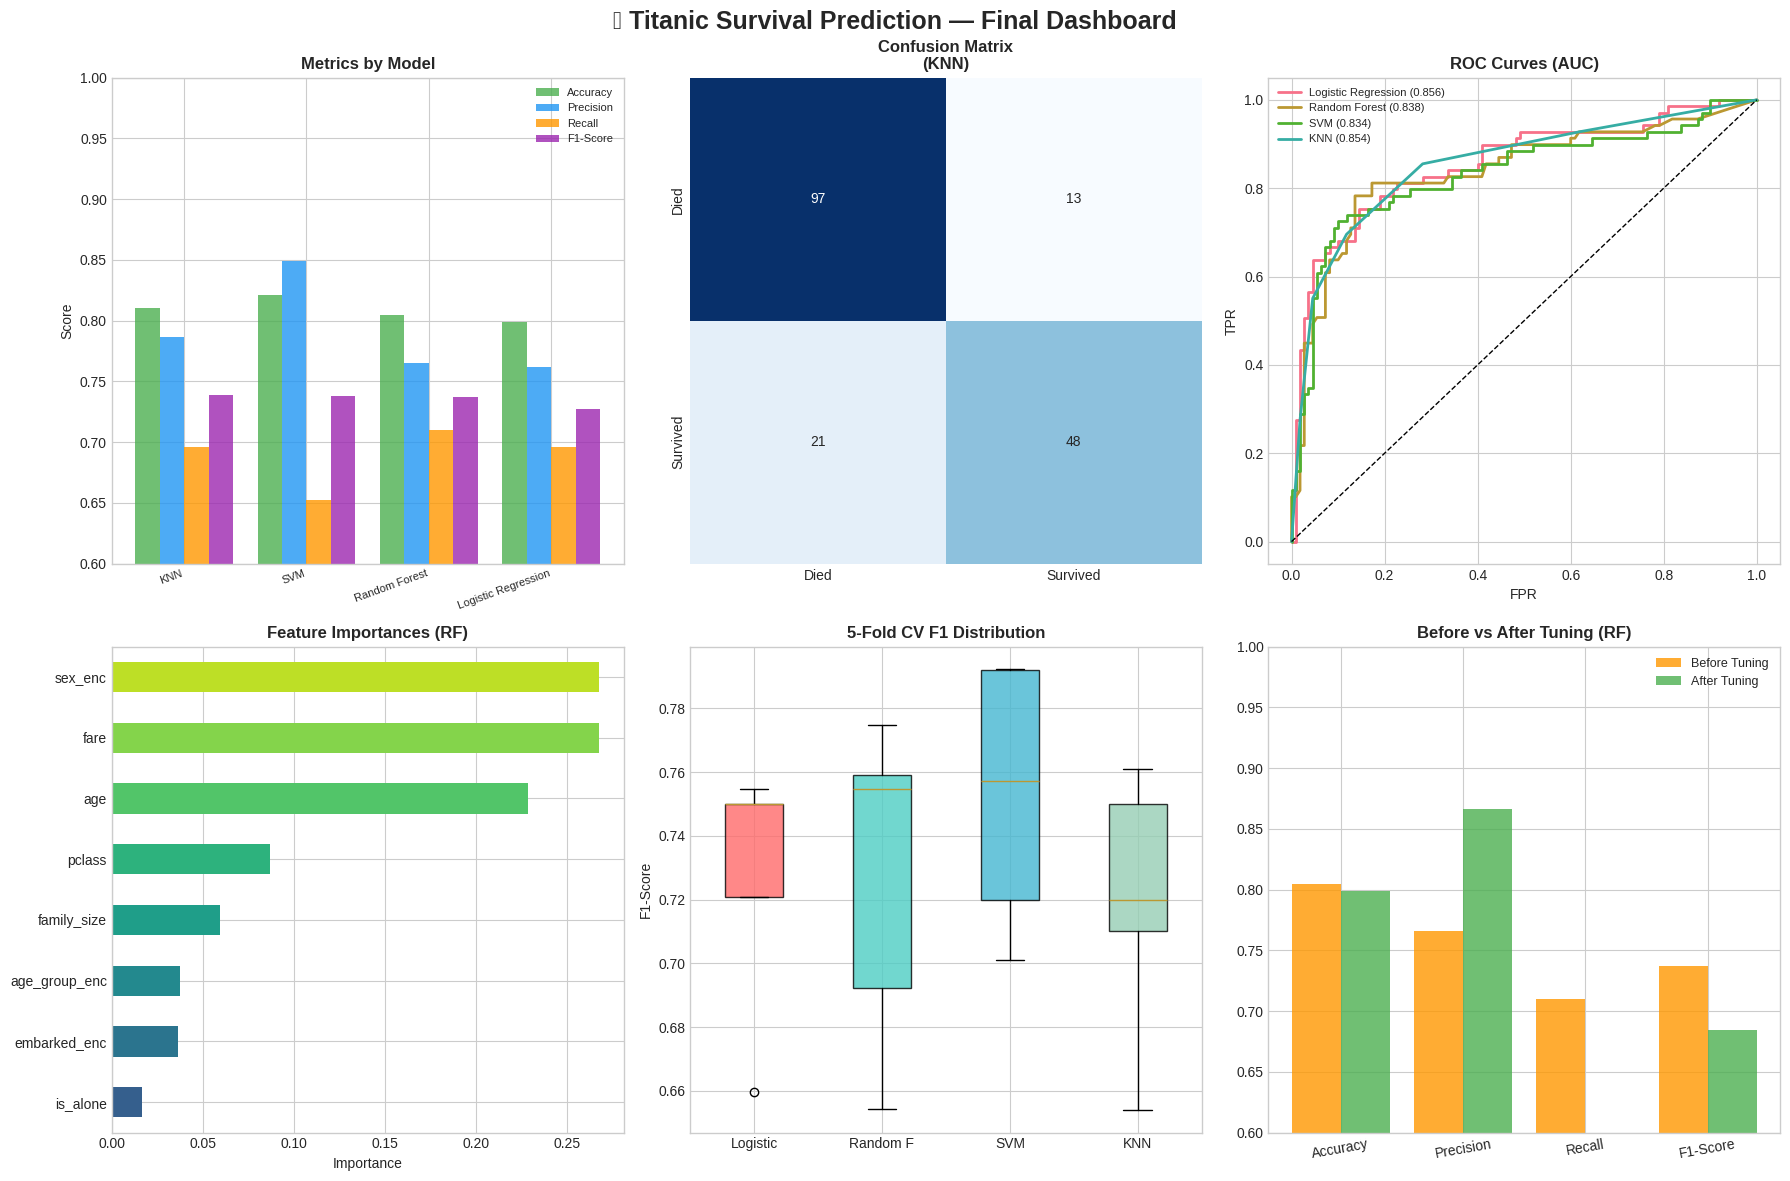


🎉 Day 6 Complete! You have mastered:
   ✅ Evaluation Metrics (Accuracy, Precision, Recall, F1)
   ✅ Confusion Matrix
   ✅ Cross-Validation (K-Fold, Stratified)
   ✅ Hyperparameter Tuning (Grid Search, Random Search)
   ✅ End-to-End ML Project (Titanic Dataset)


In [22]:
# ============================================================
# 📊 Final Visualization: Complete Dashboard
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle('🚢 Titanic Survival Prediction — Final Dashboard',
             fontsize=18, fontweight='bold', y=0.98)

# --- Plot 1: Metrics Bar Chart ---
ax1 = fig.add_subplot(2, 3, 1)
x = np.arange(len(summary_df))
width = 0.2
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors_m = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
for i, (metric, color) in enumerate(zip(metrics_list, colors_m)):
    ax1.bar(x + i*width, summary_df[metric], width, label=metric, color=color, alpha=0.8)
ax1.set_xticks(x + width*1.5)
ax1.set_xticklabels(summary_df.index, rotation=20, ha='right', fontsize=8)
ax1.set_ylabel('Score')
ax1.set_title('Metrics by Model', fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_ylim(0.6, 1.0)

# --- Plot 2: Confusion Matrix (Best Model) ---
ax2 = fig.add_subplot(2, 3, 2)
best_pred_final = titan_results[best_name]['pred']
cm_final = confusion_matrix(y_te, best_pred_final)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'], cbar=False)
ax2.set_title(f'Confusion Matrix\n({best_name})', fontweight='bold')

# --- Plot 3: ROC Curves ---
ax3 = fig.add_subplot(2, 3, 3)
for name, info in titan_results.items():
    y_prob = info['model'].predict_proba(X_te_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    ax3.plot(fpr, tpr, linewidth=2, label=f'{name} ({auc(fpr,tpr):.3f})')
ax3.plot([0,1],[0,1],'k--', linewidth=1)
ax3.set_xlabel('FPR')
ax3.set_ylabel('TPR')
ax3.set_title('ROC Curves (AUC)', fontweight='bold')
ax3.legend(fontsize=8)

# --- Plot 4: Feature Importance ---
ax4 = fig.add_subplot(2, 3, 4)
rf_final = titan_results['Random Forest']['model']
feat_imp = pd.Series(rf_final.feature_importances_, index=features).sort_values()
colors_fi = plt.cm.viridis(np.linspace(0.3, 0.9, len(features)))
feat_imp.plot(kind='barh', ax=ax4, color=colors_fi)
ax4.set_title('Feature Importances (RF)', fontweight='bold')
ax4.set_xlabel('Importance')

# --- Plot 5: CV Scores ---
ax5 = fig.add_subplot(2, 3, 5)
cv_all = {}
for name, info in titan_results.items():
    cv_all[name] = cross_val_score(info['model'], X_tr_sc, y_tr, cv=5, scoring='f1')
bp2 = ax5.boxplot(cv_all.values(), labels=[n[:8] for n in cv_all.keys()],
                  patch_artist=True)
for patch, color in zip(bp2['boxes'], ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax5.set_title('5-Fold CV F1 Distribution', fontweight='bold')
ax5.set_ylabel('F1-Score')

# --- Plot 6: Before vs After Tuning ---
ax6 = fig.add_subplot(2, 3, 6)
categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
before = [titan_results['Random Forest']['acc'],
          titan_results['Random Forest']['prec'],
          titan_results['Random Forest']['rec'],
          titan_results['Random Forest']['f1']]
y_tuned_info = gs_titan.best_estimator_.predict(X_te_sc)
after = [accuracy_score(y_te, y_tuned_info),
         precision_score(y_te, y_tuned_info),
         recall_score(y_te, y_tuned_info),
         f1_score(y_te, y_tuned_info)]
x6 = np.arange(len(categories))
ax6.bar(x6 - 0.2, before, 0.4, label='Before Tuning', color='#FF9800', alpha=0.8)
ax6.bar(x6 + 0.2, after,  0.4, label='After Tuning',  color='#4CAF50', alpha=0.8)
ax6.set_xticks(x6)
ax6.set_xticklabels(categories, rotation=10)
ax6.set_title('Before vs After Tuning (RF)', fontweight='bold')
ax6.set_ylim(0.6, 1.0)
ax6.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\n🎉 Day 6 Complete! You have mastered:')
print('   ✅ Evaluation Metrics (Accuracy, Precision, Recall, F1)')
print('   ✅ Confusion Matrix')
print('   ✅ Cross-Validation (K-Fold, Stratified)')
print('   ✅ Hyperparameter Tuning (Grid Search, Random Search)')
print('   ✅ End-to-End ML Project (Titanic Dataset)')

---

## 🏠 Practice Exercises

Try these on your own to reinforce learning:

### Exercise 1 — Different Dataset
Repeat the full pipeline using the **Iris dataset** (multi-class classification).  
Hint: Use `load_iris()` from sklearn.

### Exercise 2 — Imbalanced Data
Use `make_classification(weights=[0.9, 0.1])` to create an imbalanced dataset.  
Compare Accuracy vs F1-Score — what do you notice?

### Exercise 3 — Tuning a Different Model
Perform GridSearchCV on `SVC` with parameters:  
- `C`: [0.1, 1, 10, 100]  
- `kernel`: ['linear', 'rbf']  
- `gamma`: ['scale', 'auto']

### Exercise 4 — Group Project
Apply the complete pipeline to your group chosen dataset:  
1. Load & explore data  
2. Preprocess & engineer features  
3. Train 3+ models  
4. Evaluate with all metrics  
5. Tune the best model  
6. Present findings to the class!

---

## 📚 Reference

```python
# ── Evaluation Metrics ──────────────────────────────────────
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, classification_report, confusion_matrix)

# ── Cross-Validation ────────────────────────────────────────
from sklearn.model_selection import cross_val_score, StratifiedKFold
scores = cross_val_score(model, X, y, cv=5, scoring='f1')

# ── Hyperparameter Tuning ───────────────────────────────────
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
gs = GridSearchCV(model, param_grid, cv=5, scoring='f1')
gs.fit(X_train, y_train)
best_model = gs.best_estimator_
```

---